In [ ]:
pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 814.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.7 MB/s eta 0:00:00


Using device: cpu


Extracting qm9/raw/qm9_v3.zip
Processing...
Using a pre-processed version of the dataset. Please install 'rdkit' to alternatively process the raw data.
Done!


Train size: 100000
Validation size: 10000
Test size: 20831

Training Mean: -6.536452770233154
Training Std: 0.5977412462234497


/tmp/ipykernel_4543/1742987383.py:73: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The given 'InMemoryDataset' only references a subset of examples of the full dataset, but 'data' will contain information of the full dataset. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  train_y = train_dataset.data.y[:, target]
/tmp/ipykernel_4543/1742987383.py:84: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The given 'InMemoryDataset' only references a subset of examples of the full dataset, but 'data' will contain information of the full dataset. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppres


Epoch 1
Train Loss: 15.925740
Val RMSE: 1.921739
Val MAE: 1.474223
Val R²: -0.308541
Best model saved.

Epoch 2
Train Loss: 10.493498
Val RMSE: 1.218291
Val MAE: 0.869130
Val R²: 0.474103
Best model saved.

Epoch 3
Train Loss: 9.753461
Val RMSE: 1.787832
Val MAE: 1.461085
Val R²: -0.132536

Epoch 4
Train Loss: 9.206121
Val RMSE: 1.384531
Val MAE: 1.140365
Val R²: 0.320790

Epoch 5
Train Loss: 8.801883
Val RMSE: 1.243373
Val MAE: 0.929737
Val R²: 0.452226

Epoch 6
Train Loss: 8.241124
Val RMSE: 1.123352
Val MAE: 0.831397
Val R²: 0.552873
Best model saved.

Epoch 7
Train Loss: 7.763457
Val RMSE: 1.121522
Val MAE: 0.850410
Val R²: 0.554329
Best model saved.

Epoch 8
Train Loss: 7.243037
Val RMSE: 0.954499
Val MAE: 0.707359
Val R²: 0.677188
Best model saved.

Epoch 9
Train Loss: 6.809618
Val RMSE: 1.134742
Val MAE: 0.868331
Val R²: 0.543760

Epoch 10
Train Loss: 6.380980
Val RMSE: 0.873373
Val MAE: 0.669679
Val R²: 0.729730
Best model saved.

Epoch 11
Train Loss: 6.003056
Val RMSE: 0.9032

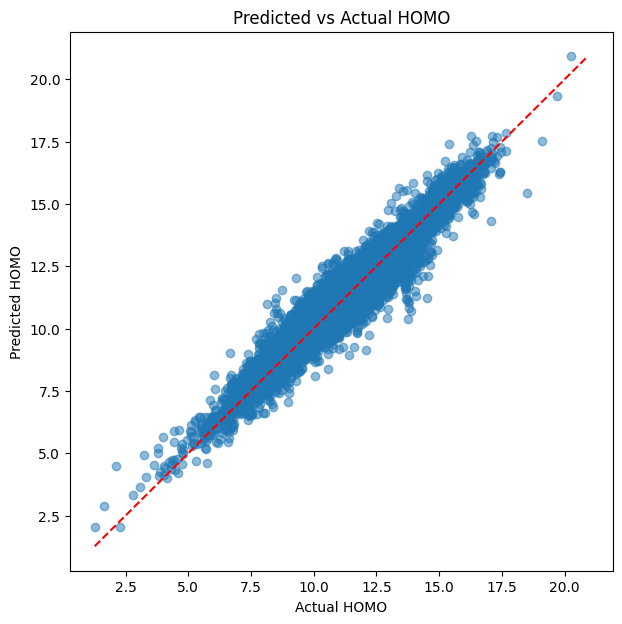

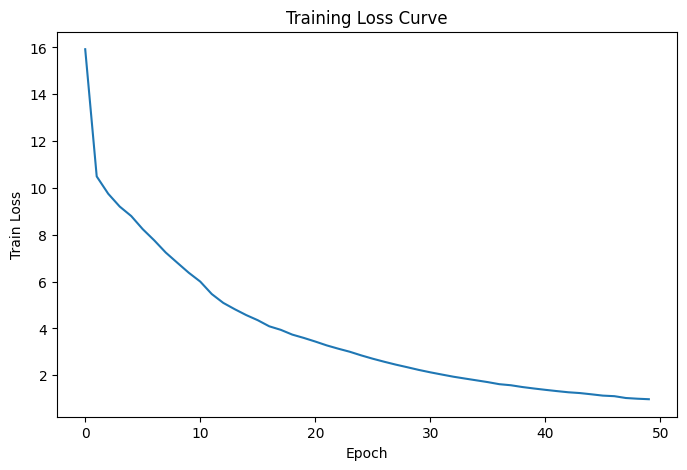


SAMPLE PREDICTIONS
Actual: 10.494307 | Predicted: 10.709064
Actual: 10.410532 | Predicted: 10.393133
Actual: 10.974112 | Predicted: 11.657219
Actual: 12.146969 | Predicted: 11.738918
Actual: 8.118130 | Predicted: 7.657956
Actual: 9.892647 | Predicted: 10.326300
Actual: 10.608545 | Predicted: 10.608385
Actual: 6.739642 | Predicted: 7.038315
Actual: 12.017498 | Predicted: 11.805527
Actual: 10.890337 | Predicted: 10.957409


In [ ]:

# HOMO PROPERTY PREDICTION USING GIN

import os
import random
import numpy as np
import torch
import torch.nn.functional as F

from torch.nn import Linear, Sequential, ReLU, BatchNorm1d, Dropout
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_add_pool

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt

# REPRODUCIBILITY

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

# LOAD DATASET

path = "./qm9"
dataset = QM9(path)

# HOMO TARGET INDEX
# QM9 target index for HOMO = 2
target = 2

# SHUFFLE DATASET

dataset = dataset.shuffle()

# TRAIN / VAL / TEST SPLIT

train_dataset = dataset[:100000]
val_dataset = dataset[100000:110000]
test_dataset = dataset[110000:]

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

# NORMALIZATION (ONLY USING TRAIN DATA)

train_y = train_dataset.data.y[:, target]

mean = train_y.mean().item()
std = train_y.std().item()

print(f"\nTraining Mean: {mean}")
print(f"Training Std: {std}")

# Normalize datasets
for split in [train_dataset, val_dataset, test_dataset]:
    split.data.y[:, target] = (
        split.data.y[:, target] - mean
    ) / std

# DATALOADERS
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# GIN MODEL

class GINNet(torch.nn.Module):

    def __init__(self, num_features):

        super(GINNet, self).__init__()

        hidden_dim = 64

        # GIN Layer 1

        nn1 = Sequential(
            Linear(num_features, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )

        self.conv1 = GINConv(nn1)
        self.bn1 = BatchNorm1d(hidden_dim)

        # GIN Layer 2

        nn2 = Sequential(
            Linear(hidden_dim, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )

        self.conv2 = GINConv(nn2)
        self.bn2 = BatchNorm1d(hidden_dim)

        # GIN Layer 3

        nn3 = Sequential(
            Linear(hidden_dim, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )

        self.conv3 = GINConv(nn3)
        self.bn3 = BatchNorm1d(hidden_dim)

        # REGRESSION HEAD

        self.lin1 = Linear(hidden_dim, 64)
        self.dropout = Dropout(0.2)
        self.lin2 = Linear(64, 1)

    def forward(self, data):

        x = data.x.float()
        edge_index = data.edge_index
        batch = data.batch

        # GIN Layers

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        # GLOBAL POOLING

        x = global_add_pool(x, batch)

        # REGRESSION HEAD

        x = self.lin1(x)
        x = F.relu(x)

        x = self.dropout(x)

        x = self.lin2(x)

        return x.squeeze()

# MODEL INITIALIZATION

model = GINNet(dataset.num_features).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

criterion = torch.nn.MSELoss()

# TRAIN FUNCTION

def train():

    model.train()

    total_loss = 0

    for data in train_loader:

        data = data.to(device)

        optimizer.zero_grad()

        pred = model(data)

        target_y = data.y[:, target]

        loss = criterion(pred, target_y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * data.num_graphs

    return total_loss / len(train_loader.dataset)

# EVALUATION FUNCTION
def evaluate(loader):

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        for data in loader:

            data = data.to(device)

            pred = model(data)

            preds.append(pred.cpu())
            targets.append(data.y[:, target].cpu())

    preds = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()

    # INVERSE NORMALIZATION

    preds_denorm = preds * std + mean
    targets_denorm = targets * std + mean

    rmse = np.sqrt(
        mean_squared_error(targets_denorm, preds_denorm)
    )

    mae = mean_absolute_error(
        targets_denorm,
        preds_denorm
    )

    r2 = r2_score(
        targets_denorm,
        preds_denorm
    )

    return rmse, mae, r2, preds_denorm, targets_denorm

# TRAINING LOOP

best_val_rmse = float("inf")

train_losses = []
val_rmses = []

epochs = 50

for epoch in range(1, epochs + 1):

    train_loss = train()

    val_rmse, val_mae, val_r2, _, _ = evaluate(val_loader)

    scheduler.step(val_rmse)

    train_losses.append(train_loss)
    val_rmses.append(val_rmse)

    print(f"\nEpoch {epoch}")

    print(f"Train Loss: {train_loss:.6f}")
    print(f"Val RMSE: {val_rmse:.6f}")
    print(f"Val MAE: {val_mae:.6f}")
    print(f"Val R²: {val_r2:.6f}")

    # SAVE BEST MODEL
    if val_rmse < best_val_rmse:

        best_val_rmse = val_rmse

        torch.save(
            model.state_dict(),
            "best_homo_model.pth"
        )

        print("Best model saved.")

# LOAD BEST MODEL

model.load_state_dict(
    torch.load("best_homo_model.pth")
)

# FINAL TEST EVALUATION

test_rmse, test_mae, test_r2, preds, targets = evaluate(test_loader)

print("\n================================================")
print("FINAL TEST RESULTS")
print("================================================")

print(f"Test RMSE : {test_rmse:.6f}")
print(f"Test MAE  : {test_mae:.6f}")
print(f"Test R²   : {test_r2:.6f}")

# PREDICTED VS ACTUAL PLOT

plt.figure(figsize=(7, 7))

plt.scatter(
    targets,
    preds,
    alpha=0.5
)

min_val = min(targets.min(), preds.min())
max_val = max(targets.max(), preds.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--'
)

plt.xlabel("Actual HOMO")
plt.ylabel("Predicted HOMO")

plt.title("Predicted vs Actual HOMO")

plt.show()

# LOSS CURVE

plt.figure(figsize=(8, 5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Train Loss")

plt.title("Training Loss Curve")

plt.show()

# SAMPLE PREDICTIONS

print("\n================================================")
print("SAMPLE PREDICTIONS")
print("================================================")

for i in range(10):

    print(
        f"Actual: {targets[i]:.6f} | "
        f"Predicted: {preds[i]:.6f}"
    )

In [ ]:
import torch
import torch.nn.functional as F

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from torch.nn import (
    Linear,
    Sequential,
    ReLU,
    BatchNorm1d,
    Dropout
)

from torch_geometric.nn import (
    GINConv,
    global_add_pool
)

Embedding Shape: (20831, 64)


PermutationExplainer explainer: 301it [00:15, 10.36it/s]
/tmp/ipykernel_4543/3622667894.py:226: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


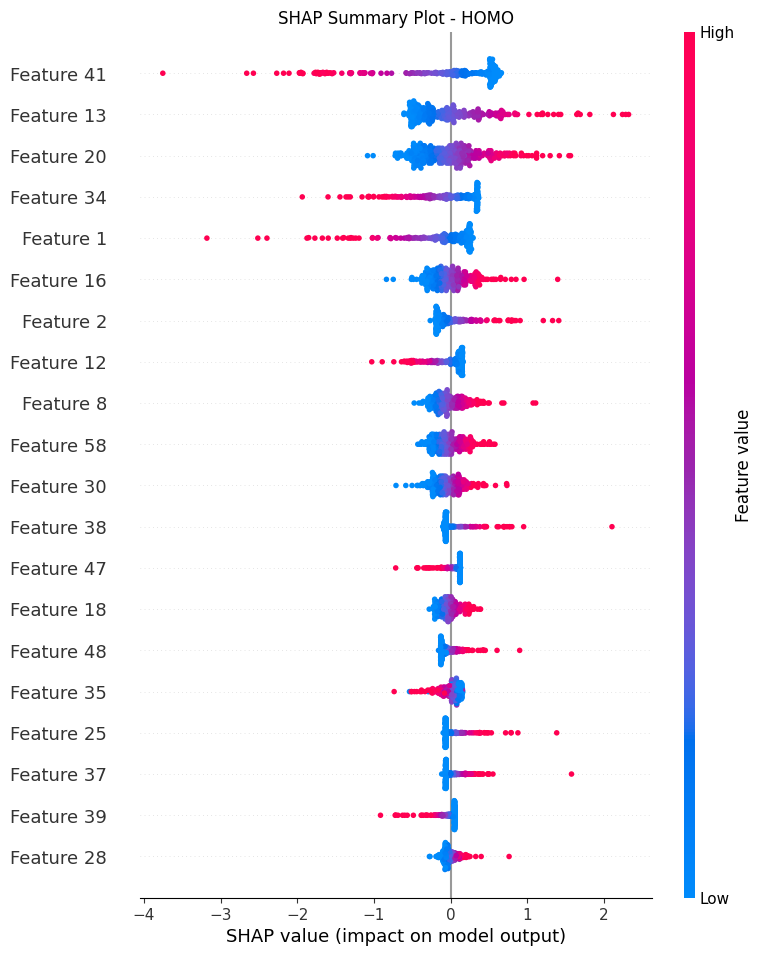

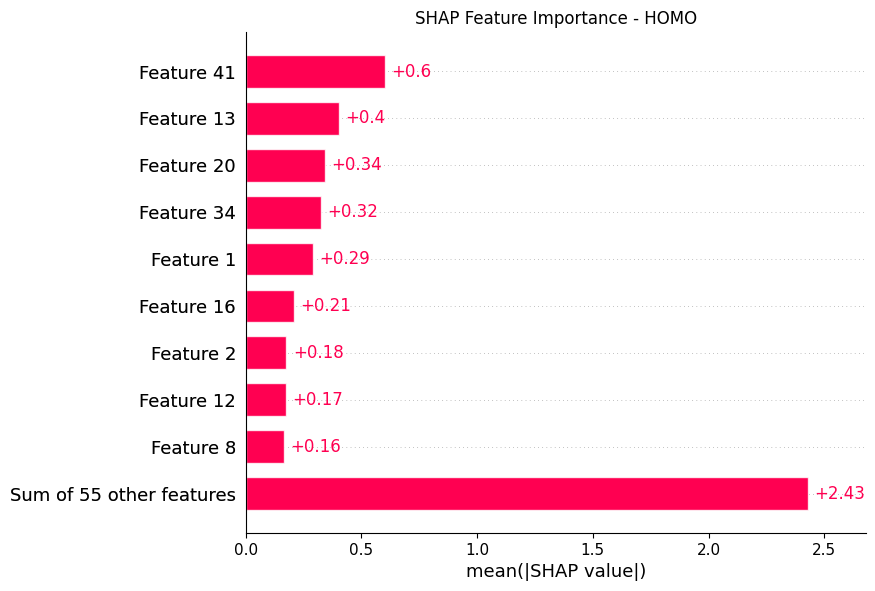


TOP IMPORTANT EMBEDDING FEATURES
    Embedding Dimension  Mean SHAP Value
41                   41         0.600281
13                   13         0.403279
20                   20         0.341973
34                   34         0.324873
1                     1         0.288664
16                   16         0.206473
2                     2         0.175741
12                   12         0.173265
8                     8         0.164069
58                   58         0.162394


In [ ]:

# SHAP ANALYSIS FOR GIN MODEL
# (Graph Embedding Explainability)


import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


class GINNet(torch.nn.Module):

    def __init__(self, num_features):

        super(GINNet, self).__init__()

        hidden_dim = 64


        # GIN Layer 1


        nn1 = Sequential(
            Linear(num_features, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )

        self.conv1 = GINConv(nn1)
        self.bn1 = BatchNorm1d(hidden_dim)


        # GIN Layer 2


        nn2 = Sequential(
            Linear(hidden_dim, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )

        self.conv2 = GINConv(nn2)
        self.bn2 = BatchNorm1d(hidden_dim)


        # GIN Layer 3


        nn3 = Sequential(
            Linear(hidden_dim, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )

        self.conv3 = GINConv(nn3)
        self.bn3 = BatchNorm1d(hidden_dim)


        # REGRESSION HEAD


        self.lin1 = Linear(hidden_dim, 64)

        self.dropout = Dropout(0.2)

        self.lin2 = Linear(64, 1)



    def forward(self, data, return_embedding=False):

        x = data.x.float()

        edge_index = data.edge_index

        batch = data.batch



        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        # GRAPH EMBEDDING


        embedding = global_add_pool(x, batch)

        # Regression Head

        out = self.lin1(embedding)

        out = F.relu(out)

        out = self.dropout(out)

        out = self.lin2(out)

        if return_embedding:
            return out.squeeze(), embedding

        return out.squeeze()

# RELOAD TRAINED MODEL


model = GINNet(dataset.num_features).to(device)

model.load_state_dict(
    torch.load("best_homo_model.pth")
)

model.eval()

#  EXTRACT EMBEDDINGS

embeddings = []
targets = []

with torch.no_grad():

    for data in test_loader:

        data = data.to(device)

        pred, emb = model(
            data,
            return_embedding=True
        )

        embeddings.append(emb.cpu().numpy())

        targets.append(
            data.y[:, target].cpu().numpy()
        )

X_embeddings = np.concatenate(embeddings, axis=0)

y_targets = np.concatenate(targets, axis=0)

print("Embedding Shape:", X_embeddings.shape)

#  REGRESSION HEAD WRAPPER

class RegressionHead(torch.nn.Module):

    def __init__(self, lin1, dropout, lin2):

        super().__init__()

        self.lin1 = lin1
        self.dropout = dropout
        self.lin2 = lin2

    def forward(self, x):

        x = torch.tensor(
            x,
            dtype=torch.float32
        ).to(device)

        x = self.lin1(x)

        x = F.relu(x)

        x = self.dropout(x)

        x = self.lin2(x)

        return x.detach().cpu().numpy()

# STEP 5 — SHAP EXPLAINER

reg_head = RegressionHead(
    model.lin1,
    model.dropout,
    model.lin2
)

# Smaller subset for speed
background = X_embeddings[:200]

sample_data = X_embeddings[200:500]

explainer = shap.Explainer(
    reg_head,
    background
)

shap_values = explainer(sample_data)

# SHAP SUMMARY PLOT

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    sample_data,
    show=False
)

plt.title("SHAP Summary Plot - HOMO")

plt.show()

#  SHAP BAR PLOT

plt.figure(figsize=(10, 6))

shap.plots.bar(
    shap_values,
    show=False
)

plt.title("SHAP Feature Importance - HOMO")

plt.show()

# FEATURE IMPORTANCE TABLE

mean_shap = np.abs(
    shap_values.values
).mean(axis=0)

feature_importance = pd.DataFrame({

    "Embedding Dimension":
    np.arange(len(mean_shap)),

    "Mean SHAP Value":
    mean_shap

})

feature_importance = feature_importance.sort_values(
    by="Mean SHAP Value",
    ascending=False
)

print("\n================================================")
print("TOP IMPORTANT EMBEDDING FEATURES")
print("================================================")

print(feature_importance.head(10))

In [ ]:
pip install lime

In [ ]:
import lime
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt

Embedding shape: (20831, 64)
Actual HOMO: 10.296291
Predicted HOMO: 11.376392


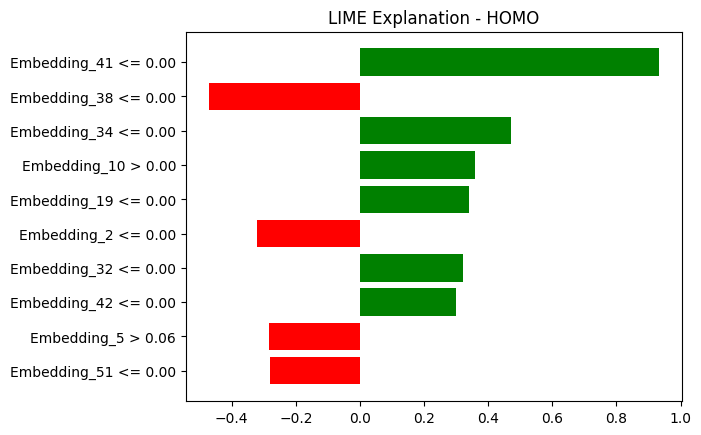


Top LIME Features:
Embedding_41 <= 0.00 : 0.9339853473977053
Embedding_38 <= 0.00 : -0.472478623517229
Embedding_34 <= 0.00 : 0.4704557549495454
Embedding_10 > 0.00 : 0.3597687653264019
Embedding_19 <= 0.00 : 0.33935924900197334
Embedding_2 <= 0.00 : -0.32104385028221055
Embedding_32 <= 0.00 : 0.3208650120606821
Embedding_42 <= 0.00 : 0.2996204771045367
Embedding_5 > 0.06 : -0.2852932174917561
Embedding_51 <= 0.00 : -0.2812748706630448


In [ ]:

# LIME FOR GNN EMBEDDING INTERPRETATION


import lime
import lime.lime_tabular
import numpy as np
import torch
import torch.nn.functional as F


# EXTRACT TEST EMBEDDINGS


model.eval()

embeddings = []
targets = []

with torch.no_grad():

    for data in test_loader:

        data = data.to(device)

        pred, emb = model(
            data,
            return_embedding=True
        )

        embeddings.append(
            emb.cpu().numpy()
        )

        targets.append(
            data.y[:, target].cpu().numpy()
        )

X_embeddings = np.concatenate(embeddings, axis=0)
y_targets = np.concatenate(targets, axis=0)

print("Embedding shape:", X_embeddings.shape)

# REGRESSION HEAD WRAPPER (NO DROPOUT)

class RegressionHead:

    def __init__(self, lin1, lin2):

        self.lin1 = lin1
        self.lin2 = lin2

    def predict(self, x):

        x = torch.tensor(
            x,
            dtype=torch.float32
        ).to(device)

        with torch.no_grad():

            x = self.lin1(x)

            x = F.relu(x)

            x = self.lin2(x)

        return x.cpu().numpy()

reg_head = RegressionHead(
    model.lin1,
    model.lin2
)


# CREATE LIME EXPLAINER

feature_names = [
    f"Embedding_{i}"
    for i in range(X_embeddings.shape[1])
]

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_embeddings,
    feature_names=feature_names,
    mode='regression'
)

# PICK ONE TEST MOLECULE

sample_index = 10

sample = X_embeddings[sample_index]

actual_normalized = y_targets[sample_index]

actual_denorm = actual_normalized * std + mean

print("Actual HOMO:", actual_denorm)

prediction = reg_head.predict(
    sample.reshape(1, -1)
)

pred_denorm = prediction[0][0] * std + mean

print("Predicted HOMO:", pred_denorm)

# GENERATE LIME EXPLANATION

exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=reg_head.predict,
    num_features=10
)

# SHOW RESULTS

fig = exp.as_pyplot_figure()

plt.title("LIME Explanation - HOMO")

plt.show()

# PRINT FEATURE CONTRIBUTIONS

print("\nTop LIME Features:")

for feature, weight in exp.as_list():
    print(feature, ":", weight)

In [ ]:
print("Target:", target)
print("Mean:", mean)
print("Std:", std)

sample_index = 10
print("Stored y:", y_targets[sample_index])

Target: 2
Mean: -6.536452770233154
Std: 0.5977412462234497
Stored y: 28.160587
